# Dataset Description (0.5 points):
Provide a brief overview of your dataset, including size, class distribution, and any peculiar characteristics. Include basic descriptive statistics.

Used Co-pilot assist which automatically helps autofill, however everything was editted and reviewed by human. I often did not use full autocomplete since it wasn't filling what I was trying to do. 

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
## expand to be able to see all rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
# from datasets import load_dataset

# from setup import load_dataset_and_save_as_csv
# df = load_dataset_and_save_as_csv()

In [2]:
data_dir = Path('../data')
df = pd.read_pickle(data_dir / "trustpilot_reviews.pkl")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123181 entries, 0 to 123180
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   category     123181 non-null  str  
 1   company      123181 non-null  str  
 2   description  123181 non-null  str  
 3   title        123181 non-null  str  
 4   review       123181 non-null  str  
 5   stars        123181 non-null  int64
dtypes: int64(1), str(5)
memory usage: 128.5 MB


In [4]:
# Size of dataset
print(f"Dataset size: {len(df)} reviews")

Dataset size: 123181 reviews


In [5]:
df.category.value_counts()

category
Education & Training            6365
Business Services               6190
Home & Garden                   6141
Sports                          6134
Food, Beverages & Tobacco       5895
Shopping & Fashion              5794
Vehicles & Transportation       5765
Money & Insurance               5729
Health & Medical                5646
Utilities                       5636
Electronics & Technology        5596
Animals & Pets                  5446
Travel & Vacation               5425
Home Services                   5387
Media & Publishing              5351
Construction & Manufacturing    5339
Hobbies & Crafts                5323
Events & Entertainment          5298
Restaurants & Bars              5204
Public & Local Services         5201
Beauty & Well-being             5199
Legal Services & Government     5117
Name: count, dtype: int64

In [44]:
print(f'Number of unique categories: {df.category.nunique()}')

Number of unique categories: 22


Even distribution of classes, which is good for training a model for category detection.

In [45]:
print(f'Number of unique companies: {df.company.nunique()}')

Number of unique companies: 1680


In [7]:
df.company.value_counts().head()

company
www.ukjuicers.com          100
www.perfume-click.co.uk    100
www.holisticshop.co.uk     100
nutritiongeeks.co          100
www.zipvit.co.uk           100
Name: count, dtype: int64

Max number of review per company is 100 reviews. No one company dominating the dataset. 

In [8]:
## add a review_count feature
df["review_count"] = df.groupby("company")["company"].transform("count")
df.head()

,category,company,description,title,review,stars,review_count
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5,59
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5,59
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5,59
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5,59
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5,59


In [9]:
unique_companies_cnt = df['company'].nunique()
print(f"Number of unique companies in dataset: {unique_companies_cnt}")

Number of unique companies in dataset: 1680


In [10]:
#how many companies have each number of reviews 
print("Number of companies with each review count:")
print(df.groupby('review_count')['company'].nunique().sort_index(ascending=False))

Number of companies with each review count:
review_count
100    558
99     137
98      50
97      20
96      16
95      12
94       8
93       7
92       8
91      10
90      10
89       6
88       3
87      10
86       9
85       8
84      13
83      15
82       9
81      10
80      17
79      14
78       9
77      13
76      15
75       9
74      10
73      10
72       9
71      12
70      12
69       9
68      12
67       8
66       6
65       8
64      12
63      12
62       7
61       4
60       8
59      12
58      13
57      10
56      11
55       9
54       8
53       4
52      11
51       8
50       5
49       8
48      10
47      13
46      11
45       8
44      11
43       8
42      14
41       9
40      12
39       9
38       6
37       5
36       8
35       7
34       7
33      13
32      13
31      12
30       9
29      13
28      14
27      18
26      18
25      17
24      16
23      26
22      18
21      33
20      34
19       3
17       1
15       6
13       2
12      

In [11]:
cnt_100 = df.groupby('review_count')['company'].nunique().get(100, 0)
print(f"Count of companies with 100 reviews: {cnt_100}")
print(f"Percentage of companies with 100 reviews: {cnt_100/unique_companies_cnt*100:.2f}%")

Count of companies with 100 reviews: 558
Percentage of companies with 100 reviews: 33.21%


In [12]:
## company aggregate df 
df_company = df.groupby('company').agg({'review_count':'first'}).reset_index()
df_company.sort_values('review_count', ascending=False).head()

,company,review_count
1679,zopa.com,100
1322,www.londontheatre.co.uk,100
587,nonnatonda.co.uk,100
1314,www.leisurelakesbikes.com,100
590,nutritiongeeks.co,100


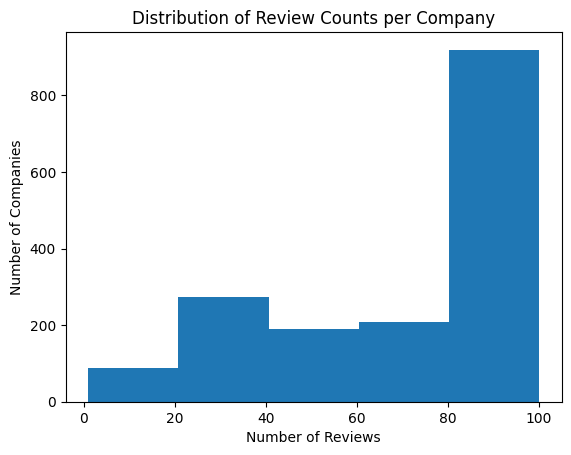

In [13]:
## plot the distribution of review counts
plt.hist(df_company['review_count'], bins=5)
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Companies')
plt.title('Distribution of Review Counts per Company')
plt.show()

Most companies have 100 + reviews. 

In [14]:
df['over_80_reviews'] = df['review_count'] > 80
df.head()

,category,company,description,title,review,stars,review_count,over_80_reviews
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5,59,False
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5,59,False
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5,59,False
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5,59,False
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5,59,False


In [46]:
# how many companies have over/ under 80 reviews?
print('Companies with over 80 reviews:', df[df['over_80_reviews']==True]['company'].nunique())
print('Companies with under 80 reviews:', df[df['over_80_reviews']==False]['company'].nunique())

print('Percentage of companies with over 80 reviews:', df[df['over_80_reviews']==True]['company'].nunique()/unique_companies_cnt*100)
print('Percentage of companies with under 80 reviews:', df[df['over_80_reviews']==False]['company'].nunique()/unique_companies_cnt*100)

Companies with over 80 reviews: 919
Companies with under 80 reviews: 761
Percentage of companies with over 80 reviews: 54.702380952380956
Percentage of companies with under 80 reviews: 45.29761904761905


The distribution of reviews per category is even but within each category, the distribution of reviews per company is uneven. This may effect our model. Unsure how at the moment. Perhaps I can look at the distribution of companies that have over 80 reviews and see the catetegory distribution. 

In [16]:
df[df['over_80_reviews']==True]['category'].value_counts()

category
Vehicles & Transportation       5476
Home & Garden                   5300
Media & Publishing              5044
Travel & Vacation               4937
Shopping & Fashion              4934
Utilities                       4806
Money & Insurance               4710
Electronics & Technology        4656
Health & Medical                4407
Construction & Manufacturing    4313
Sports                          4123
Business Services               4078
Education & Training            4041
Animals & Pets                  3716
Home Services                   3696
Beauty & Well-being             3693
Legal Services & Government     3684
Events & Entertainment          3640
Public & Local Services         3164
Hobbies & Crafts                3123
Restaurants & Bars              2848
Food, Beverages & Tobacco       1446
Name: count, dtype: int64

In [47]:
df[df['over_80_reviews']==True]['company'].nunique()

919

In [18]:
## how many categories by company?
df.groupby('company')['category'].nunique().value_counts()

## every company has one category

category
1    1680
Name: count, dtype: int64

The category distribution become more uneven if we were to filter out for companies with less than 80 reviews. 

We likely want to ignore the companies all together and base our categorization only on the review text and title. 
Because the company names are likely to be very predictive of the category, and we want to avoid data leakage.

If we were instead categorizing star rank it would be interesting to see if the number of review correlates to the ranking. In future models we can use review count as a feature. 


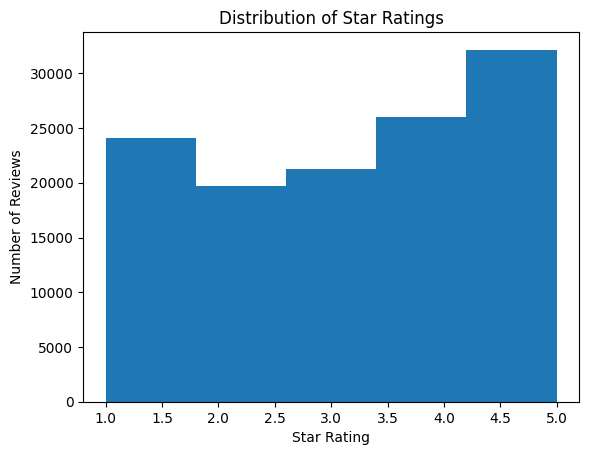

In [19]:
## plot the distribution of stars 
plt.hist(df['stars'], bins=5)
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Star Ratings')
plt.show()

Asked Claude to create a single plot instead of the many plots I had before, so I can see all the categories in one place without the need for scolling.

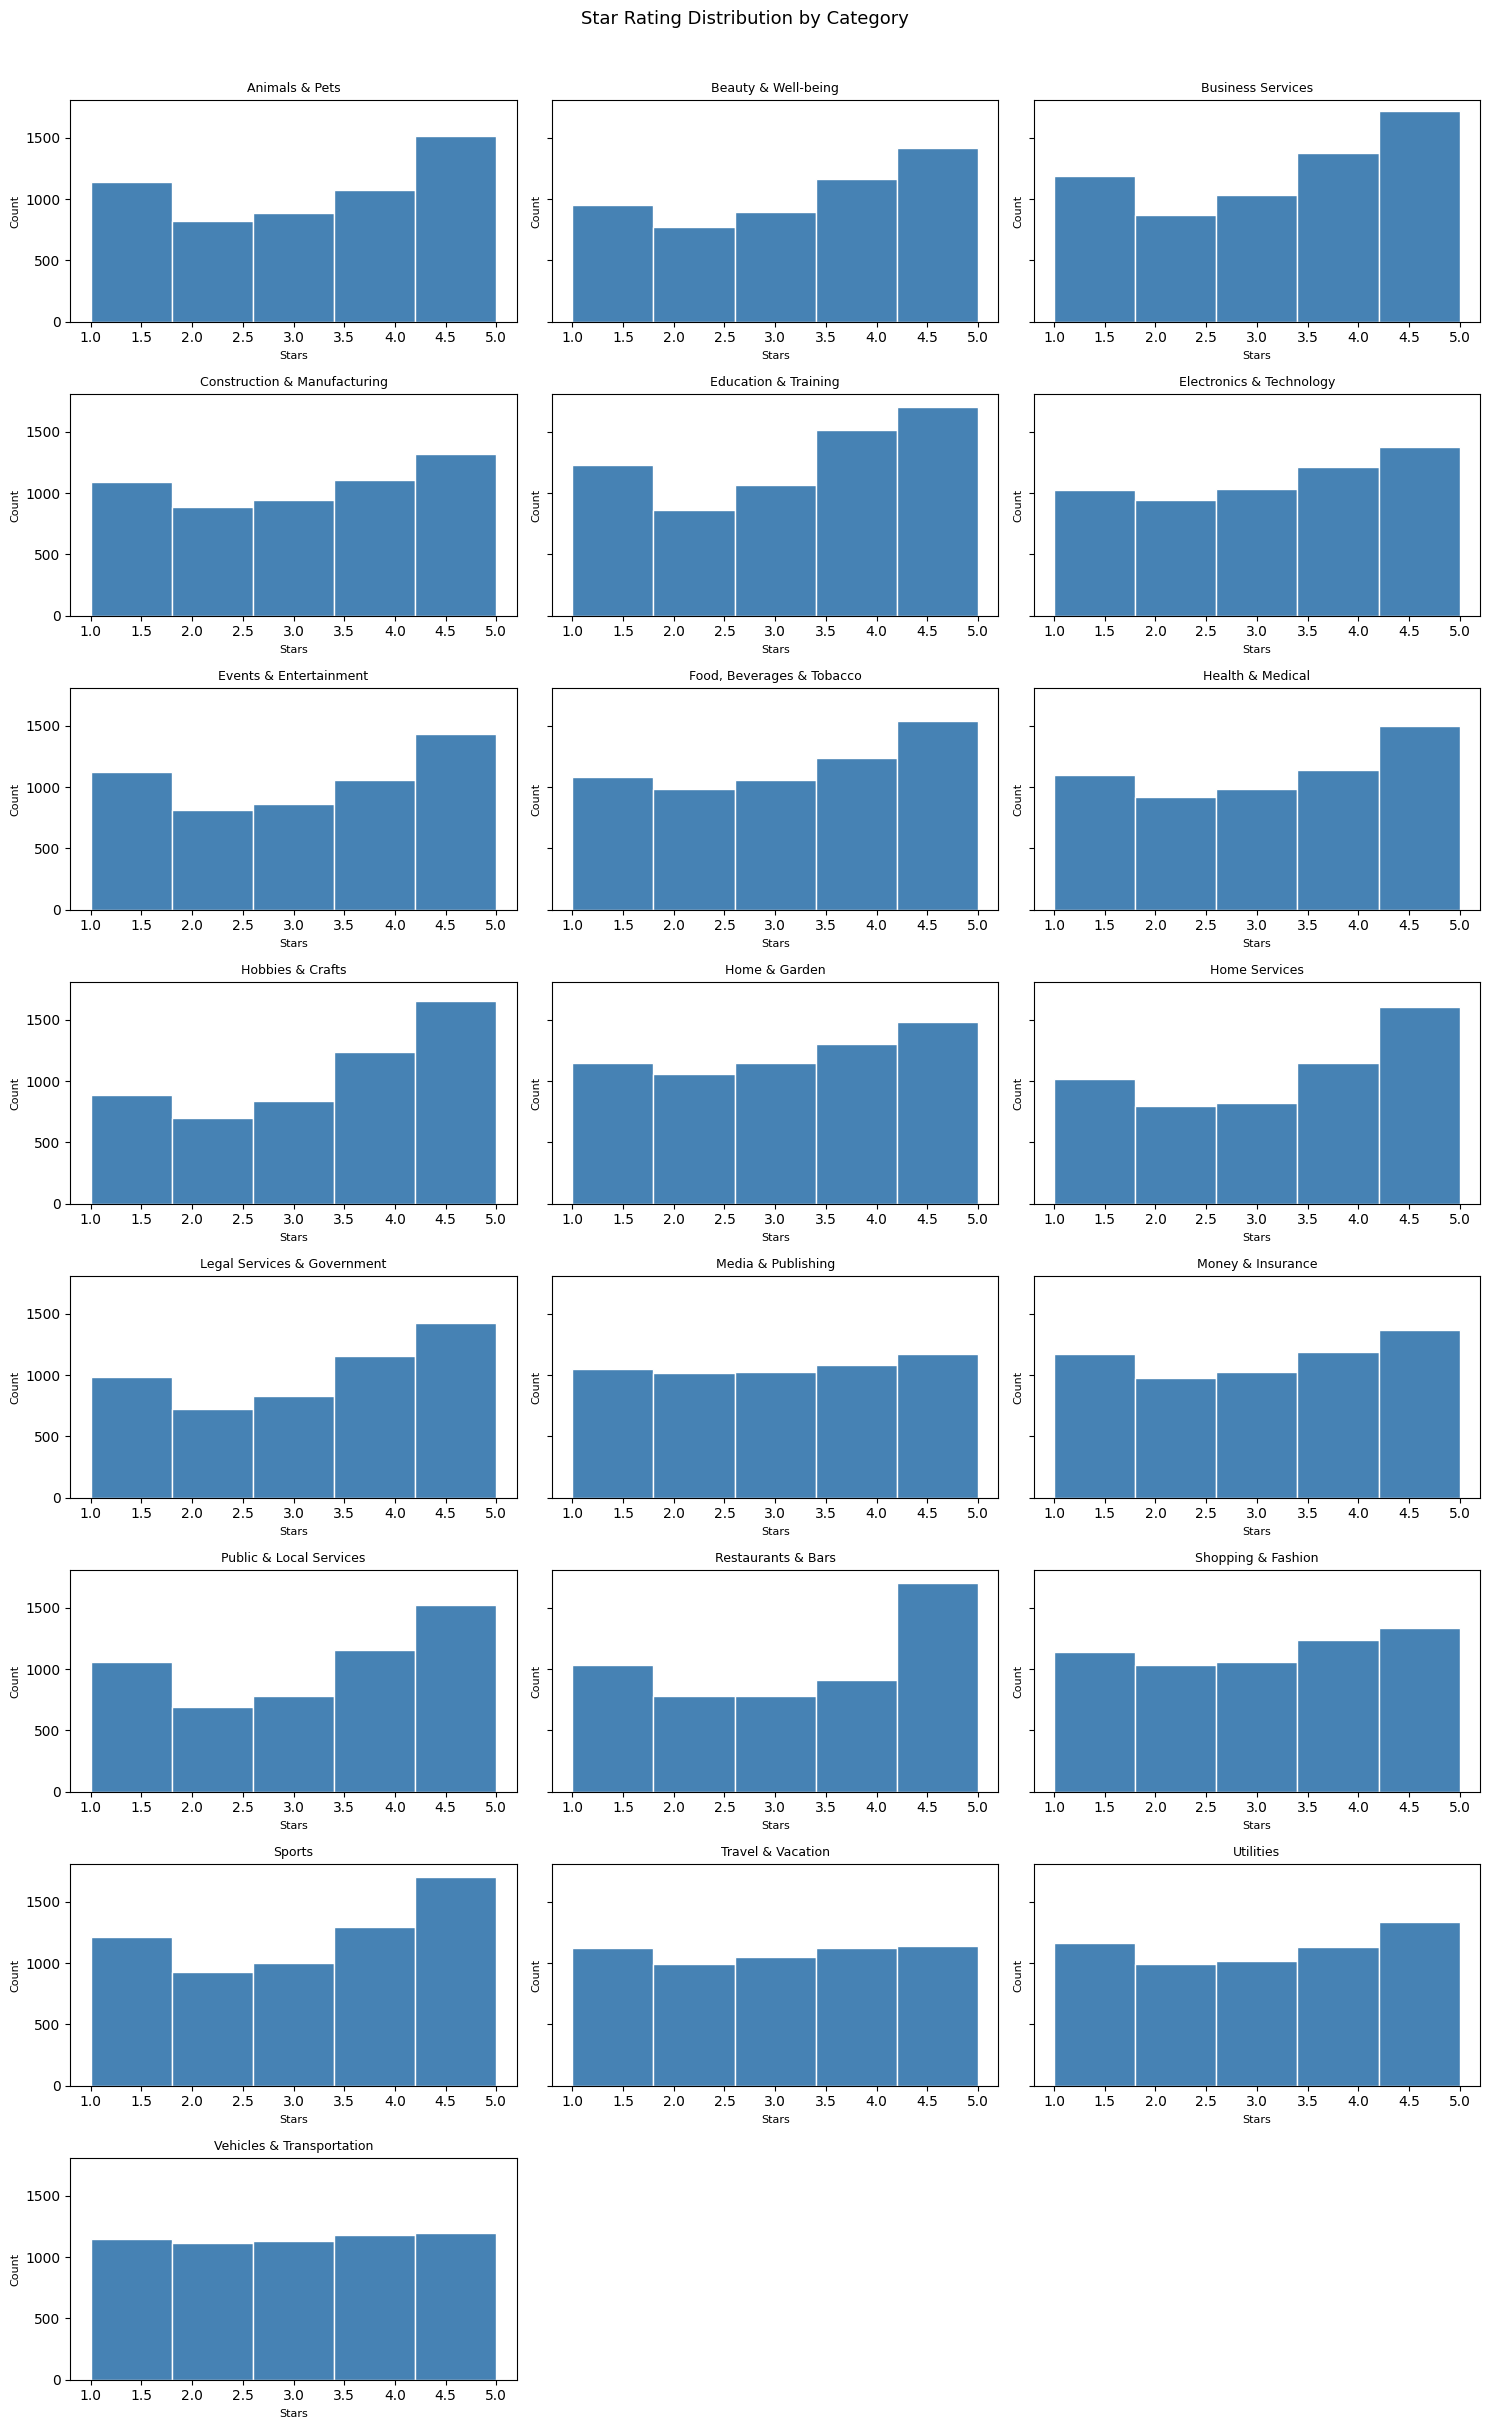

In [20]:
# Distribution of star ratings by category — faceted plot
categories = df['category'].unique()
n_cats = len(categories)
n_cols = 3
n_rows = (n_cats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3), sharey=True)
axes = axes.flatten()

for i, category in enumerate(sorted(categories)):
    category_data = df[df['category'] == category]
    axes[i].hist(category_data['stars'], bins=5, color='steelblue', edgecolor='white')
    axes[i].set_title(category, fontsize=9)
    axes[i].set_xlabel('Stars', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Star Rating Distribution by Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/star_distribution_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
df['stars'].value_counts()

stars
5    32152
4    26013
1    24065
3    21264
2    19687
Name: count, dtype: int64

## is this distibution of stars balanced?

Normalized value counts to true gives us the proportion of each star rating. 

In [22]:
df['stars'].value_counts(normalize=True).sort_index(ascending=False)

stars
5    0.261014
4    0.211177
3    0.172624
2    0.159822
1    0.195363
Name: proportion, dtype: float64

Overall distribution is, 26% of reviews are 5 stars, 21% are 4 stars, 17% are 3 stars, 16% are 2 stars, and 19% are 1 star.
This shows us that its not fully balanced. Its not awful but we may have a harder time predicting the 2 and 3 star rating. It may be more worth while choosing categories that are more balanced.  

In [23]:
df.groupby('category')['stars'].value_counts(normalize=True).unstack()


stars,1,2,3,4,5
category,,,,,
Animals & Pets,0.209512,0.151304,0.162872,0.197760,0.278553
Beauty & Well-being,0.182343,0.147913,0.172726,0.224082,0.272937
Business Services,0.191922,0.141195,0.167367,0.221809,0.277706
Construction & Manufacturing,0.204345,0.166511,0.176063,0.206593,0.246488
Education & Training,0.192616,0.135271,0.166850,0.237863,0.267400
Electronics & Technology,0.183167,0.169228,0.184775,0.217298,0.245533
Events & Entertainment,0.211589,0.154209,0.163458,0.199698,0.271046
"Food, Beverages & Tobacco",0.183715,0.166921,0.179135,0.209500,0.260729
Health & Medical,0.195182,0.163479,0.174106,0.201913,0.265321


Next, we created a balance measurement feature for dataset to rank how balanced each category is in terms of star ratings. Since visaully on the plot we have an idea but we wanted a less arbitrary way to measure. We compute a Gini-Simpson diversity index for each category's star rating distribution. The index is defined as 1 − Σp², where p is the proportion of each star rating. A value close to 1 indicates a highly uniform distribution across star ratings, while a value close to 0 indicates the distribution is dominated by a single rating. This helps identify which product categories have the most balanced vs. skewed review sentiment.

In [24]:
def balance_measure(group):
    """ Compute balance measure for a group of reviews 
    A high balance measure indicates that the distribution of star ratings is more uniform, 
    while a low balance measure indicates that the distribution is more skewed towards certain star ratings.
    """
    star_counts = group['stars'].value_counts(normalize=True)
    balance = 1 - sum(star_counts**2)
    return balance
df_category_balance = df.groupby('category').apply(balance_measure).reset_index(name='balance_measure')
df_category_balance.sort_values('balance_measure', ascending=False)

,category,balance_measure
21,Vehicles & Transportation,0.799866
19,Travel & Vacation,0.799472
13,Media & Publishing,0.799459
17,Shopping & Fashion,0.798051
20,Utilities,0.797690
14,Money & Insurance,0.797121
10,Home & Garden,0.797072
5,Electronics & Technology,0.796165
3,Construction & Manufacturing,0.796082
7,"Food, Beverages & Tobacco",0.794427


From here we got the idea that we would choose two topics of interest that are highly balanced to use for our project. This we can frame as a consultancy which works with these industries.

In [25]:
travel_n_media = df[df['category'].isin(['Travel & Vacation', 'Media & Publishing'])]

travel_n_media.groupby('category')['stars'].value_counts(normalize=True).unstack()


stars,1,2,3,4,5
category,,,,,
Media & Publishing,0.196786,0.189497,0.192301,0.202579,0.218838
Travel & Vacation,0.207558,0.183226,0.192811,0.207005,0.209401


Here we look at the raw data to see what we can learn contextually just from the company names

In [26]:
df[df.category =="Media & Publishing"].company.unique()

<ArrowStringArray>
[        'www.loopmasters.com',                   'popsa.com',
              'pocketmags.com',              'www.amazon.com',
                 'www.hmv.com',           'www.viewsbank.com',
          'www.snapfish.co.uk',                 'www.sky.com',
          'www.vinyltap.co.uk',                  'cewe.co.uk',
       'www.designmynight.com',             'getinthemix.com',
         'horizonsmusic.co.uk',     'www.stringsdirect.co.uk',
       'www.musicmatter.co.uk',               'wonderbly.com',
    'bookshop.blackwell.co.uk',            'worldofbooks.com',
                 'www.bbc.com',                     'eil.com',
              'www.juno.co.uk',              'www.yupptv.com',
          'planetoffers.co.uk',           'www.musicroom.com',
             'www.getmein.com',        'www.isubscribe.co.uk',
          'www.dittomusic.com',          'www.gear4music.com',
            'foliosociety.com',               'www.gak.co.uk',
                    'qmee.com',     

We saw that amazon is on the list of companies so decided to see if it is one company like amazon that is contributing to the even star distribution. To ask ourselves for example if we didn't have amazon review would our dataset suffer?

In [27]:
## We saw that the max number of reviews for a company is 100, just checking amazon here since it is a well known company and should have 100 reviews
df[df['company'] == 'www.amazon.com'].category.value_counts()

category
Media & Publishing    100
Name: count, dtype: int64

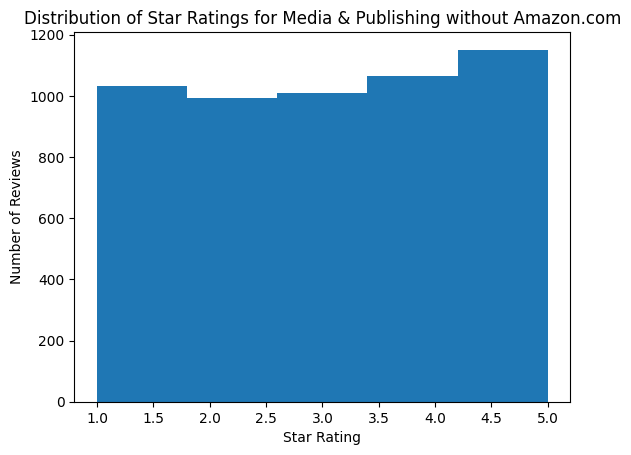

In [28]:
## distribution of stars for media and publishing without amazon.com
media_publishing_no_amazon = df[(df['category'] == "Media & Publishing") & (df['company'] != 'www.amazon.com')]

plt.hist(media_publishing_no_amazon['stars'], bins=5)
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Star Ratings for Media & Publishing without Amazon.com')
plt.show()

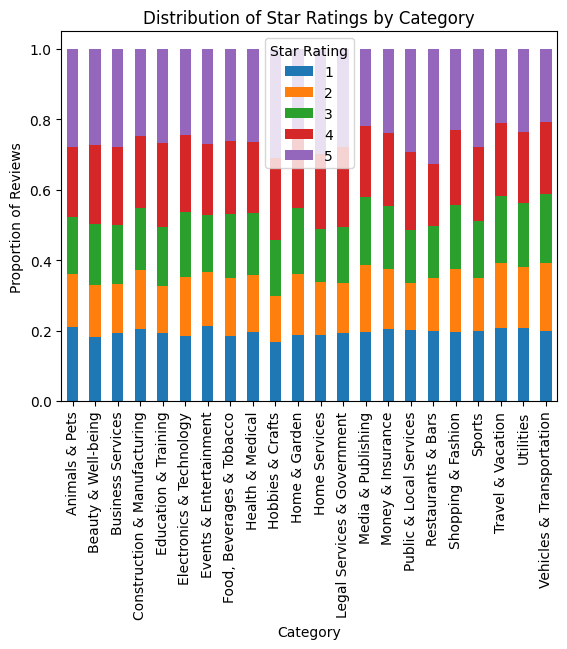

In [29]:
## star rating by category
df.groupby('category')['stars'].value_counts(normalize=True).unstack().fillna(0)

#show plot of star ratings by category
df.groupby('category')['stars'].value_counts(normalize=True).unstack().fillna(0).plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Proportion of Reviews')
plt.title('Distribution of Star Ratings by Category')
plt.legend(title='Star Rating') 
plt.show()

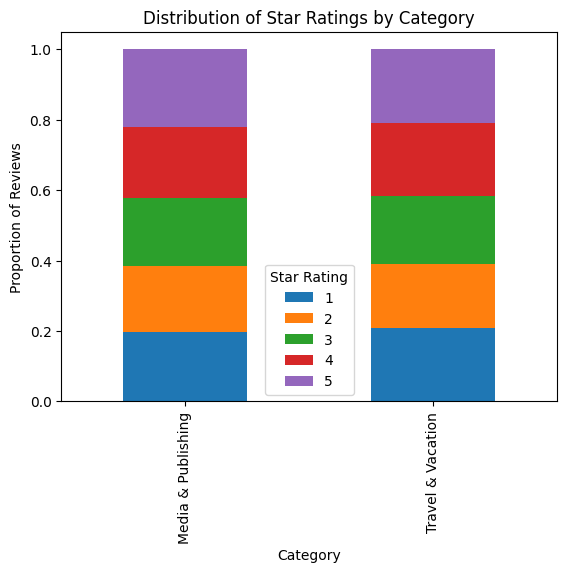

In [30]:
travel_n_media.groupby('category')['stars'].value_counts(normalize=True).unstack().fillna(0)

#show plot of star ratings by category
travel_n_media.groupby('category')['stars'].value_counts(normalize=True).unstack().fillna(0).plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Proportion of Reviews')
plt.title('Distribution of Star Ratings by Category')
plt.legend(title='Star Rating') 
plt.show()

Less skewed to either positive or negative than I expected. We could consider categorizing the star rating instead of the category. 

## Looking at the text

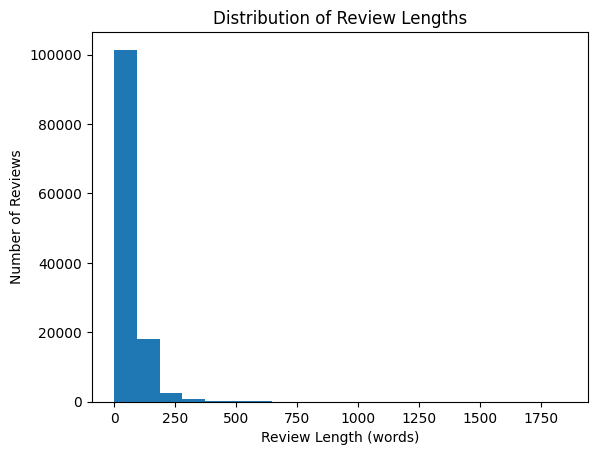

In [31]:
#reviews length distribution
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
plt.hist(df['review_length'], bins=20)
plt.xlabel('Review Length (words)')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Lengths')
plt.show()

In [32]:
df['review_length'].describe()

count    123181.000000
mean         64.535529
std          57.174870
min           1.000000
25%          31.000000
50%          52.000000
75%          80.000000
max        1852.000000
Name: review_length, dtype: float64

The reviews are mostly short text which is something to keep in mind when we are selecting the models used/ may impact our performance.

The mean lenght is 52 which is longer then a tweet or video comment but still relevative short when compared to articles, transcripts, etc. 
There some outliers with a max length of 1852 but the 75th percentile is only 80 words, so the majority of reviews are quite short.


In [33]:
## what is the description 
# how many descriptions are there?
df['description'].nunique()
df.company.nunique()

1680

One description per company. It is the description of the company, not the review. So it is not useful for our task of classifying reviews. We will drop it in preprocessing.

In [34]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
import string


In [35]:
## get most common words in reviews for each category

def get_common_words(reviews, n=20, STOPWORDS_ADDTIONAL= None):
    ## remove punctuation and stopwords
    reviews = [review.translate(str.maketrans('', '', string.punctuation)) for review in reviews] ## remove punctuation
    reviews = [review.lower() for review in reviews] ## lowercase
    stopwords_to_remove = set(stopwords.words('english')) ## get stopwords
    reviews = [[word for word in review.split() if word not in stopwords_to_remove] for review in reviews] ## remove stopwords
    # ## remove 'movie' and 'film' as they are common in all reviews and not informative
    common_words = STOPWORDS_ADDTIONAL if STOPWORDS_ADDTIONAL is not None else set()
    reviews = [[word for word in review if word not in common_words] for review in reviews]
    all_words = [word for review in reviews for word in review] ## flatten list of lists
    word_counts = Counter(all_words) # count word frequencies
    return word_counts.most_common(n) ## get n most common words



In [36]:
# get df for each category to then get common words for each category

def get_common_words_by_category(df, category_col='category', review_col='review', n=20, STOPWORDS_ADDTIONAL= None):
    categories = df[category_col].unique()
    common_words_by_category = {}
    for category in categories:
        reviews = df[df[category_col] == category][review_col].tolist()
        common_words_by_category[category] = get_common_words(reviews, n, STOPWORDS_ADDTIONAL)
    return common_words_by_category

In [37]:
common_words_dict = get_common_words_by_category(df)

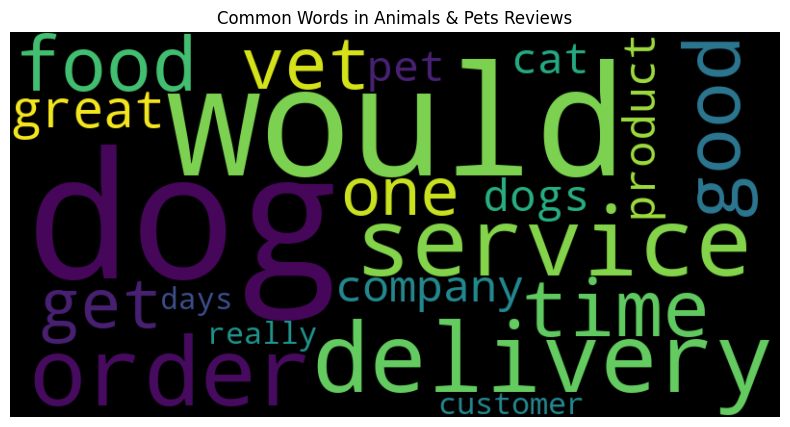

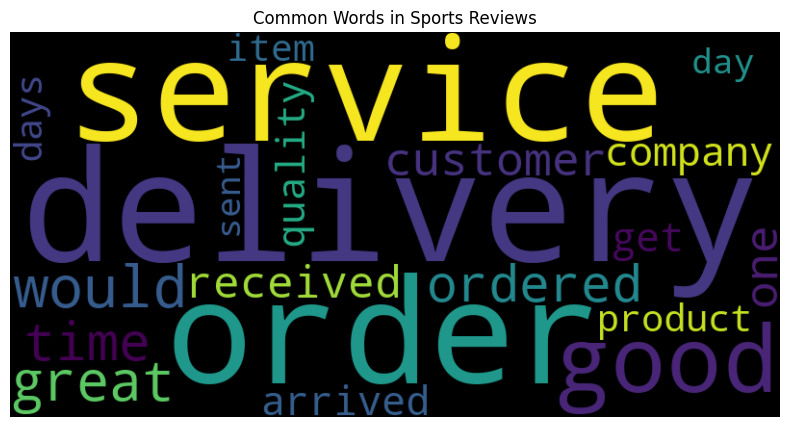

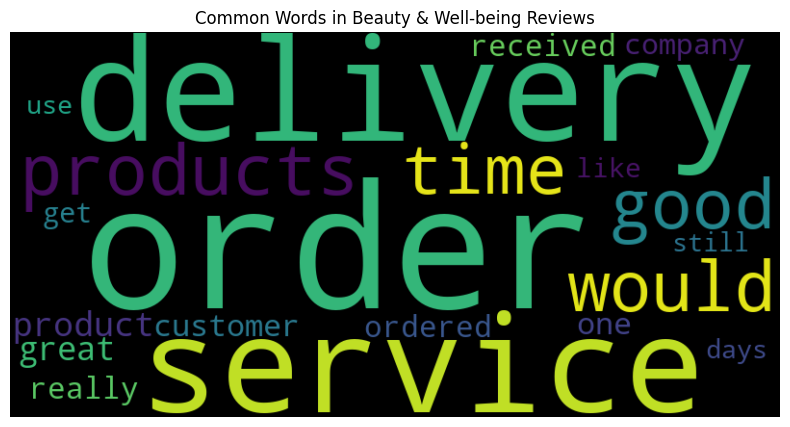

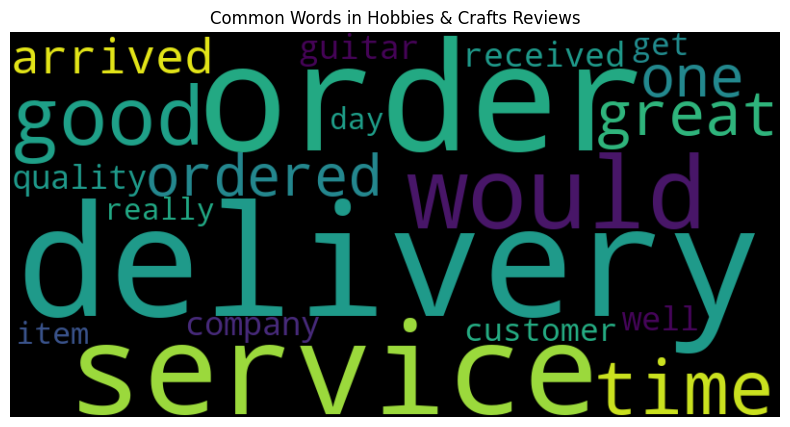

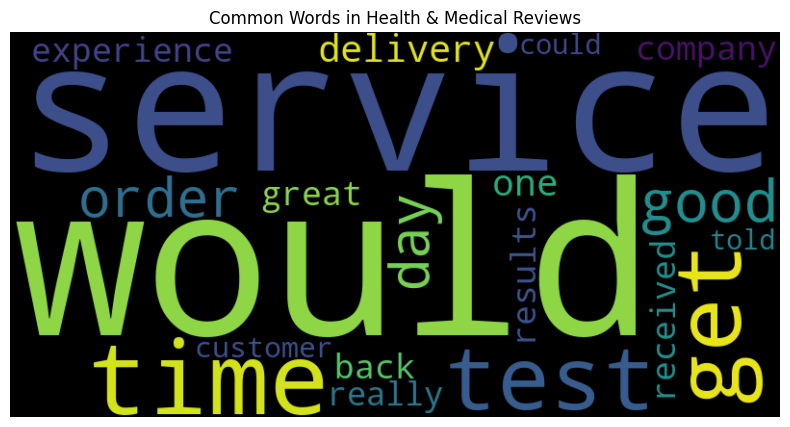

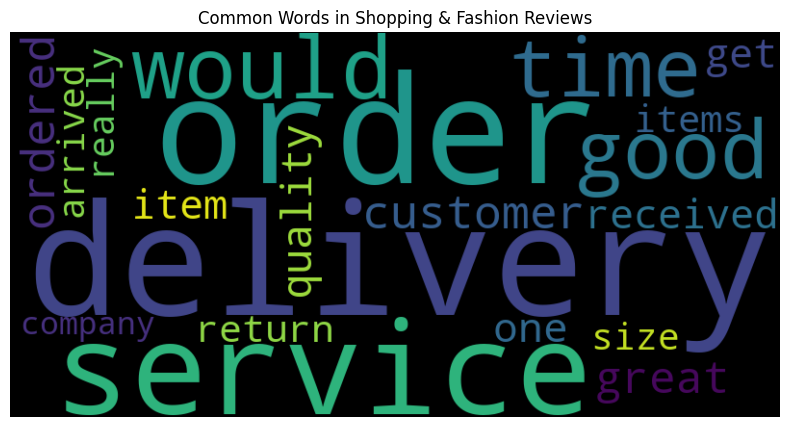

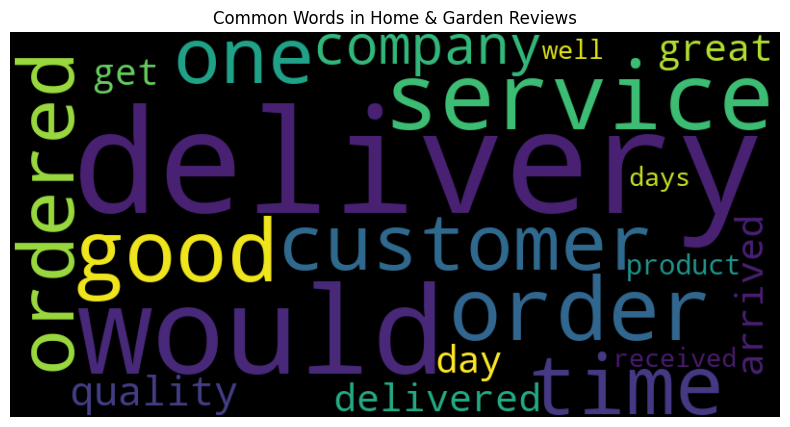

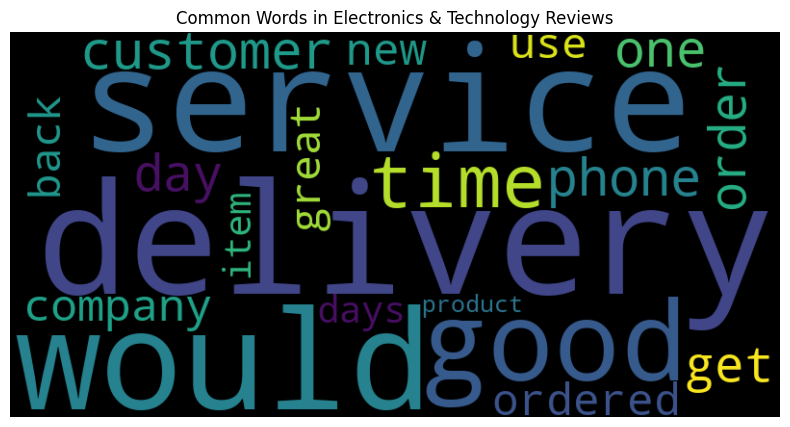

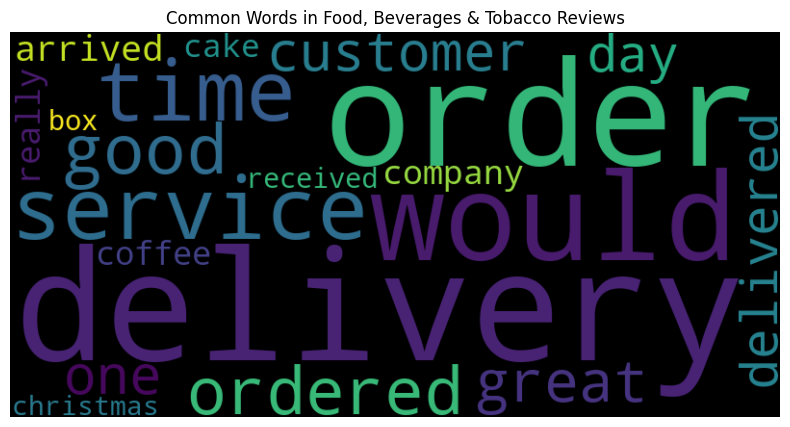

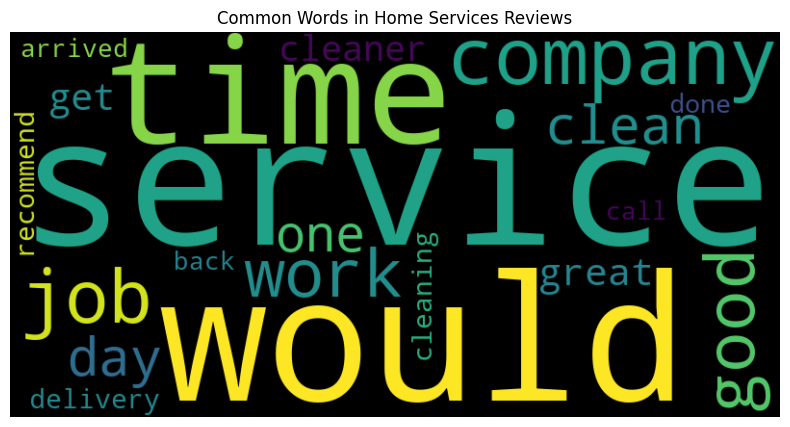

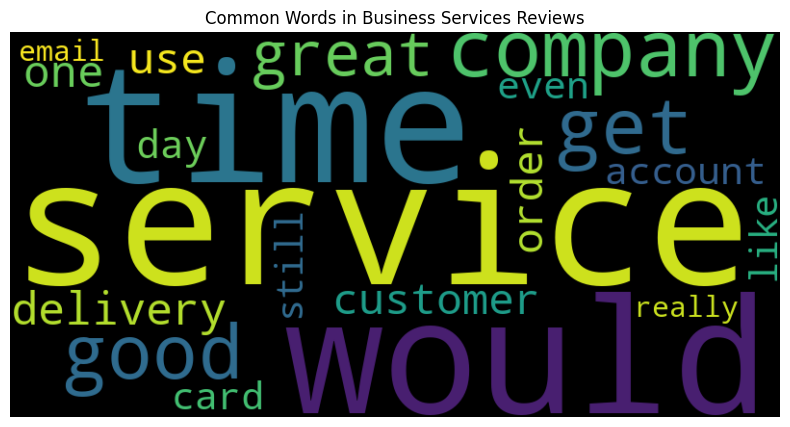

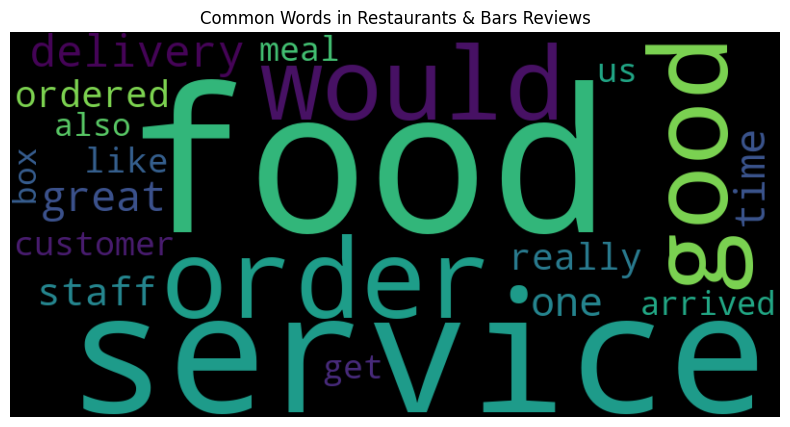

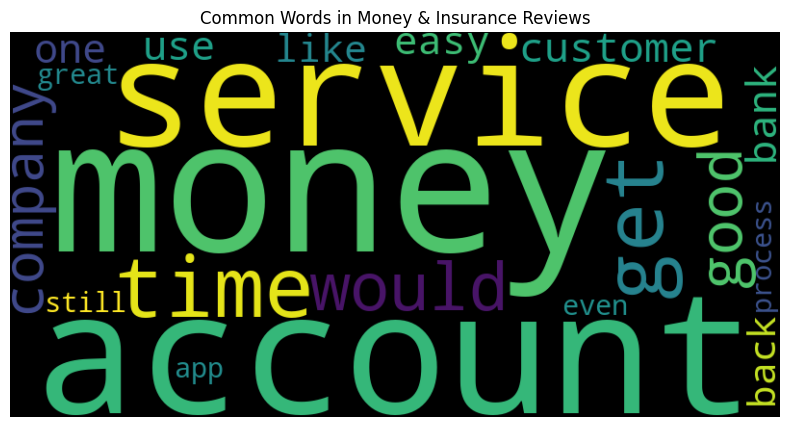

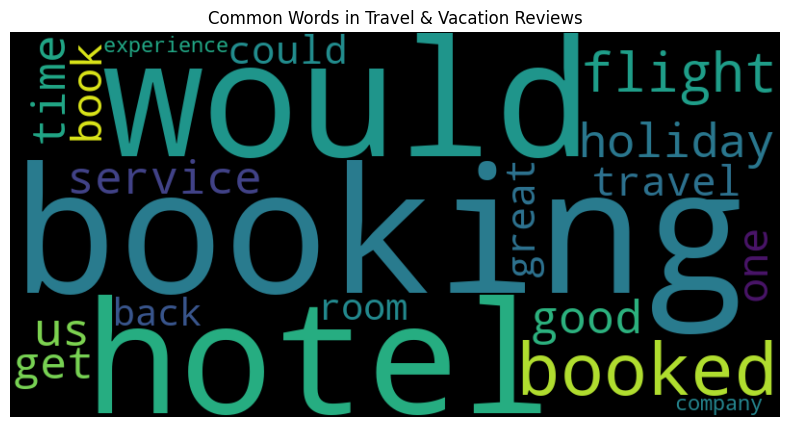

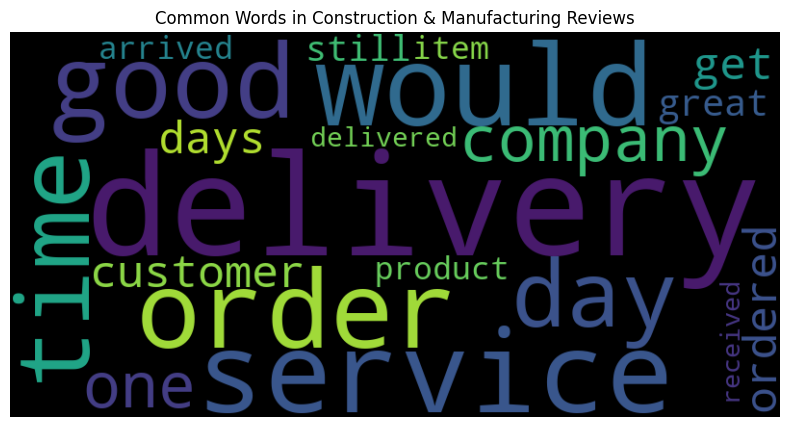

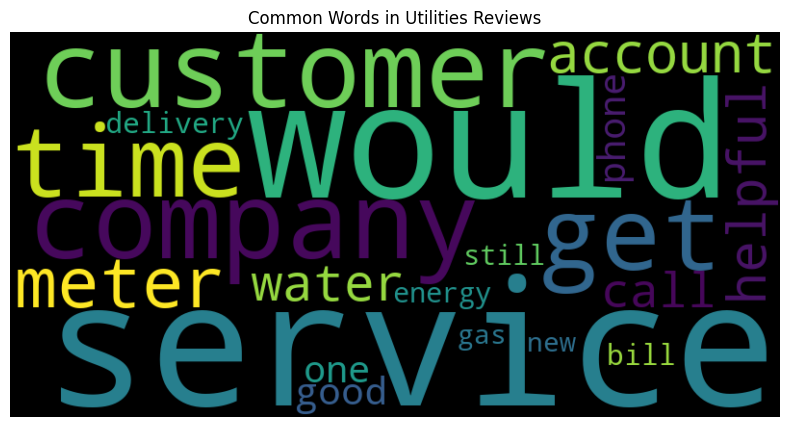

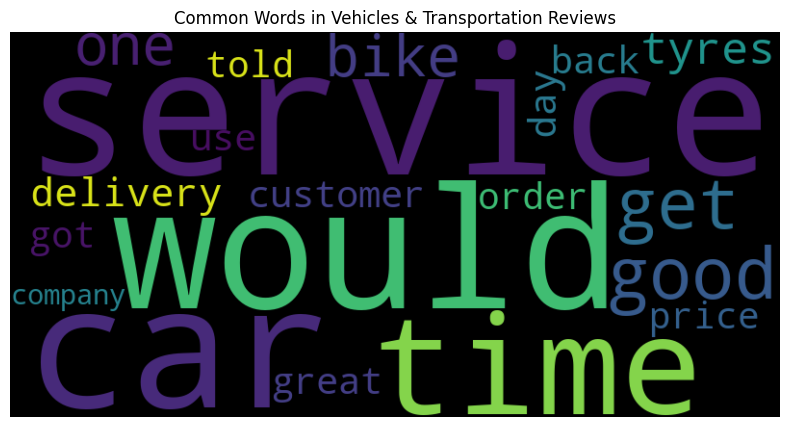

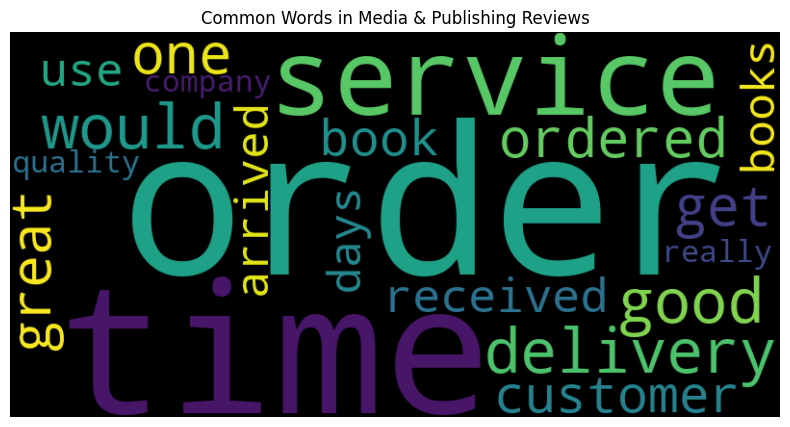

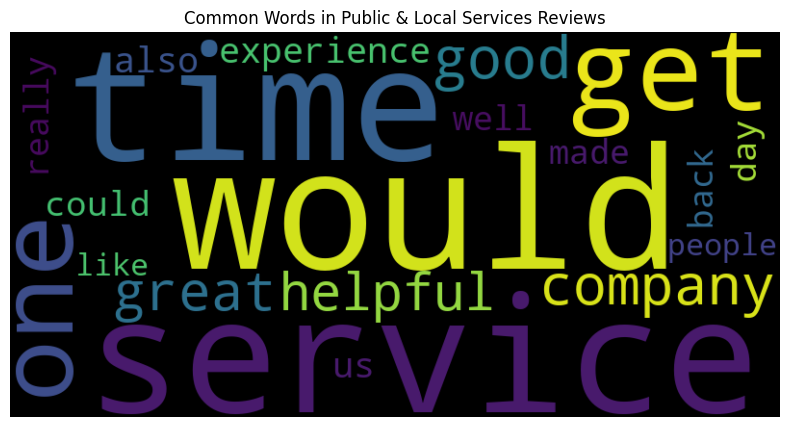

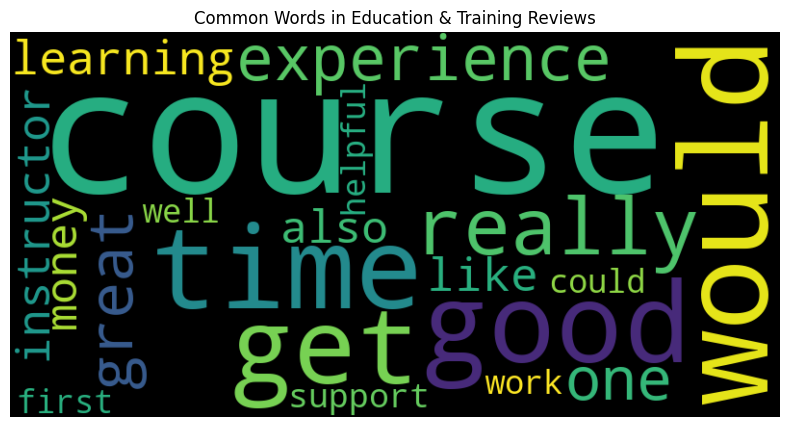

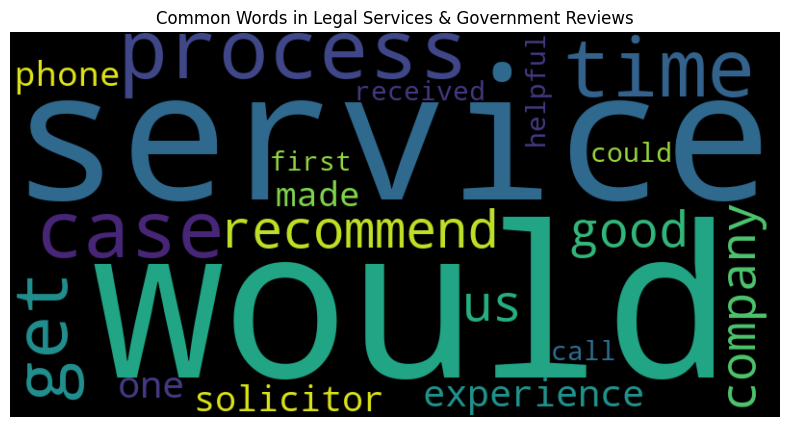

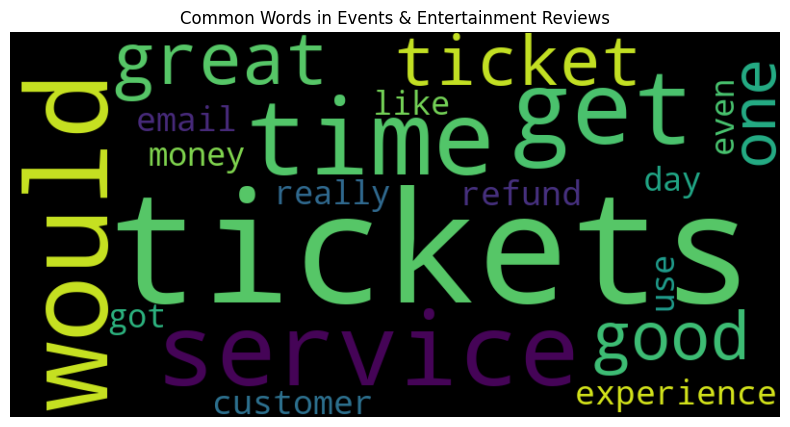

In [38]:
##use dict to get wordcloud for each category
from wordcloud import WordCloud
for category, common_words in common_words_dict.items():
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(dict(common_words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Common Words in {category} Reviews')
    plt.show()

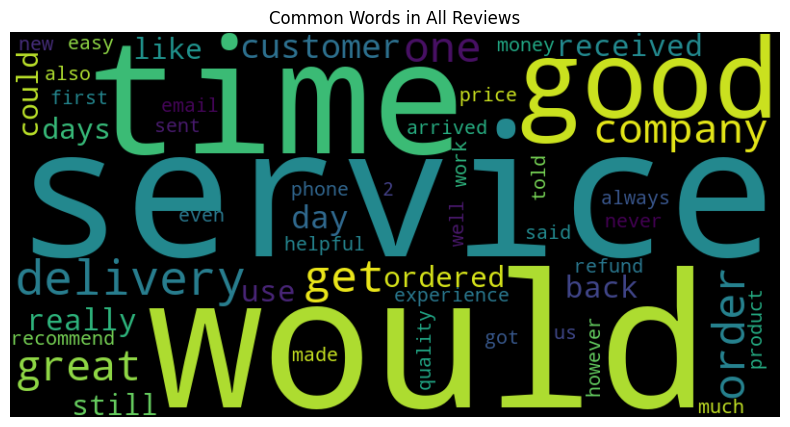

In [39]:
## commmon words in all reviews
all_reviews = df['review'].tolist()
common_words_all = get_common_words(all_reviews, n=50)
wordcloud_all = WordCloud(width=800, height=400).generate_from_frequencies(dict(common_words_all))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in All Reviews')
plt.show()

In [40]:
# top 20 common words in all reviews
common_words_all[:20]

## get in a list of words
common_words_all_list = [word for word, count in common_words_all]
common_words_all_list[:50]

['would',
 'service',
 'time',
 'good',
 'delivery',
 'get',
 'order',
 'one',
 'great',
 'company',
 'customer',
 'day',
 'really',
 'use',
 'back',
 'received',
 'ordered',
 'could',
 'still',
 'days',
 'like',
 'experience',
 'also',
 'even',
 'well',
 'got',
 'email',
 'arrived',
 'first',
 'money',
 'helpful',
 '2',
 'made',
 'told',
 'recommend',
 'us',
 'easy',
 'however',
 'sent',
 'never',
 'new',
 'much',
 'always',
 'work',
 'phone',
 'quality',
 'product',
 'price',
 'said',
 'refund']

As expected words like 'delivery','service', 'order' are commons for reviews in every category. We need to add stop words that are common in customer reviews that would not tell us anything about the category of the product. 

In [41]:
STOPWORDS_ADDTIONAL = common_words_all_list[:50]

In [42]:
edited_word_dict = get_common_words_by_category(df, STOPWORDS_ADDTIONAL=STOPWORDS_ADDTIONAL)

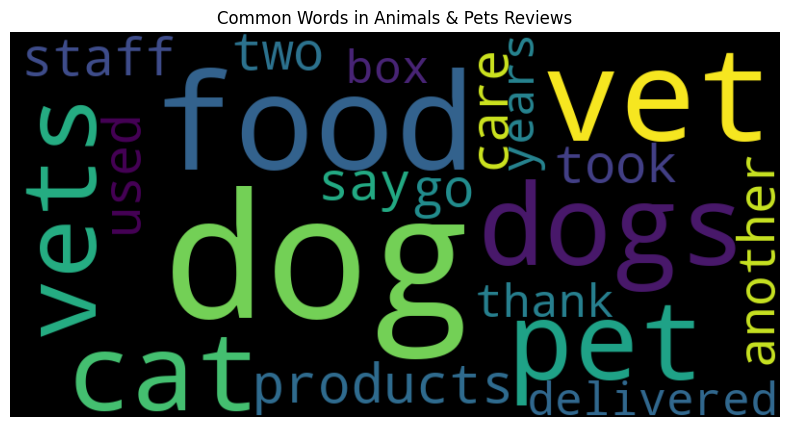

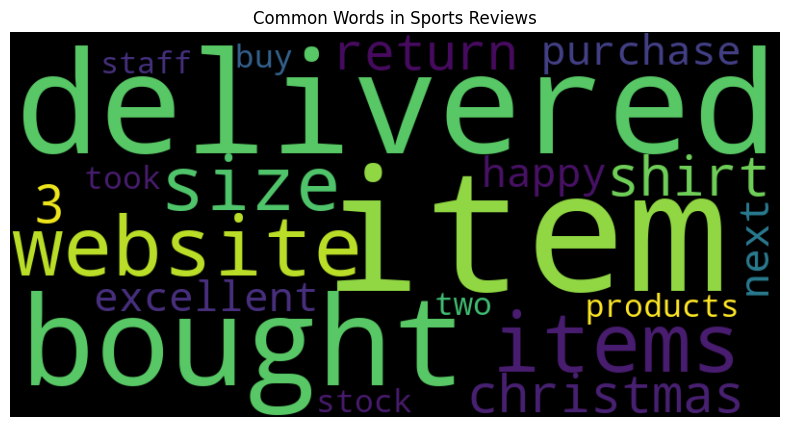

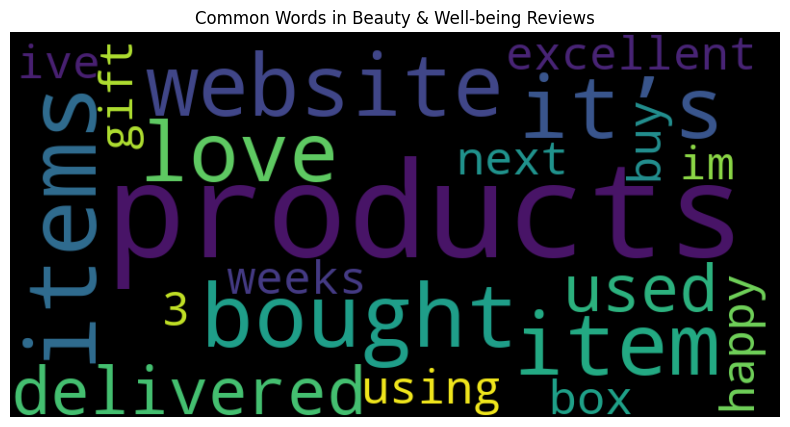

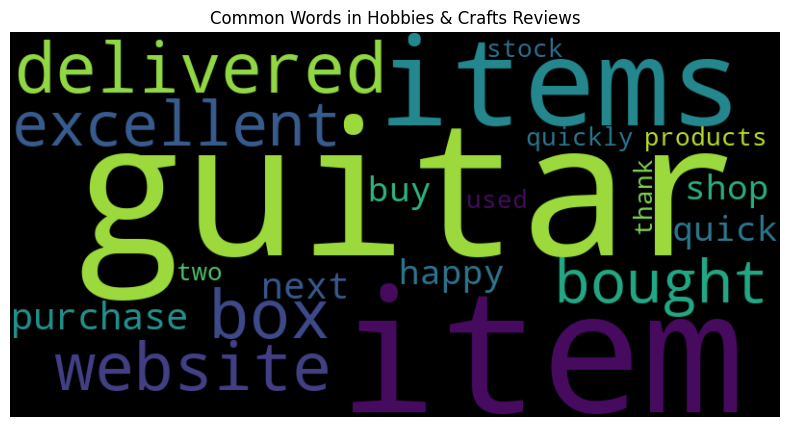

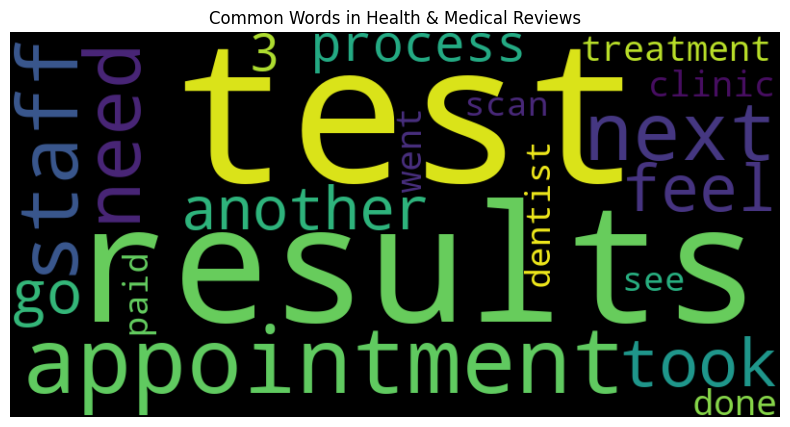

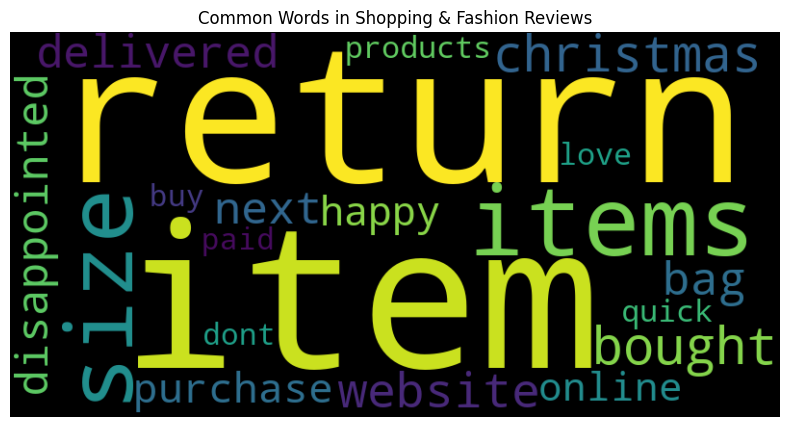

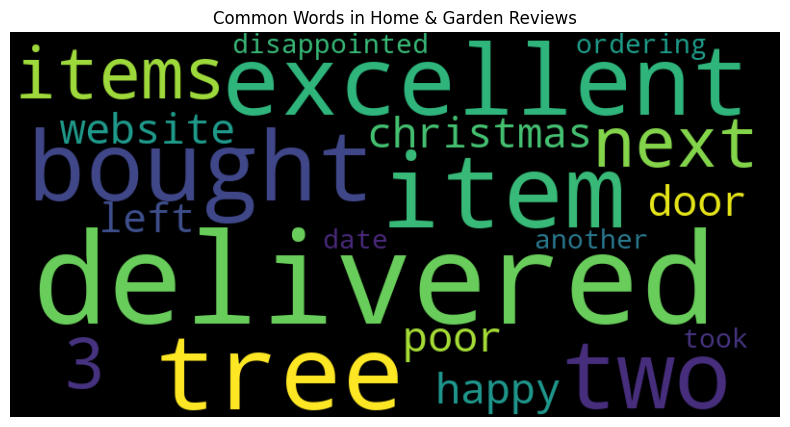

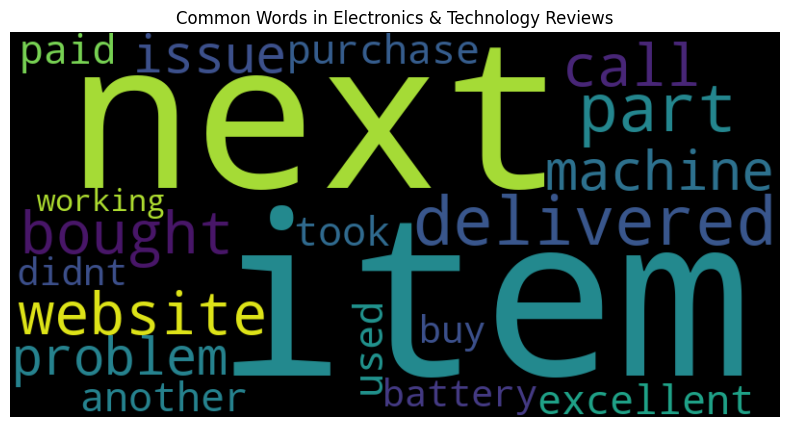

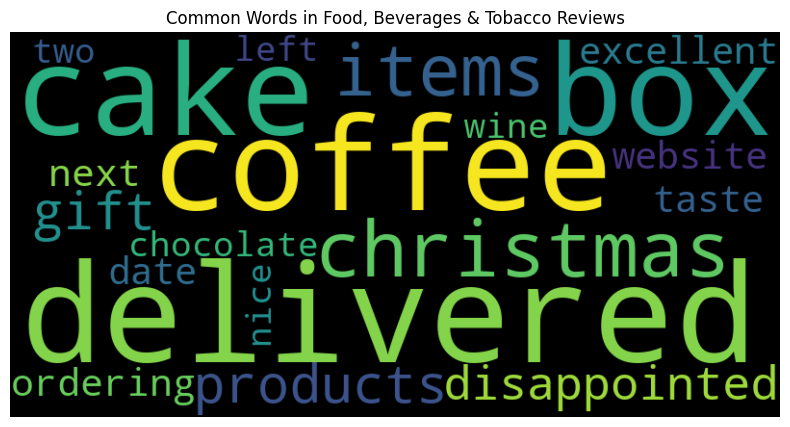

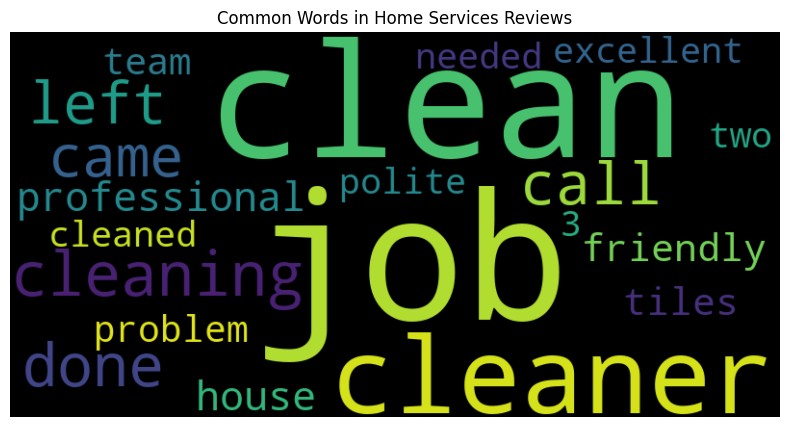

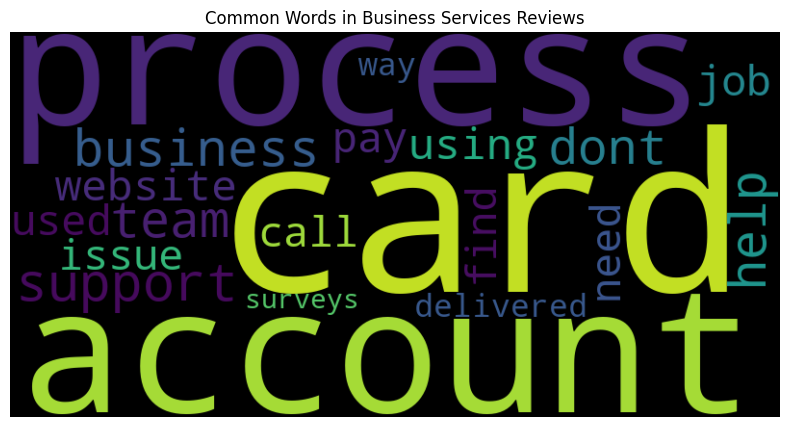

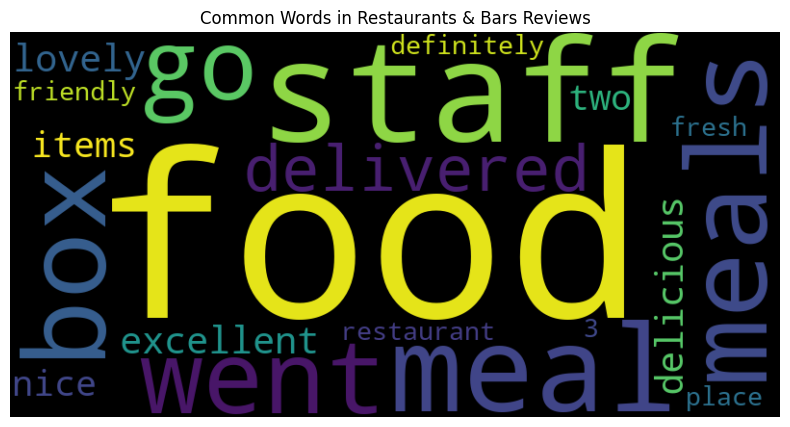

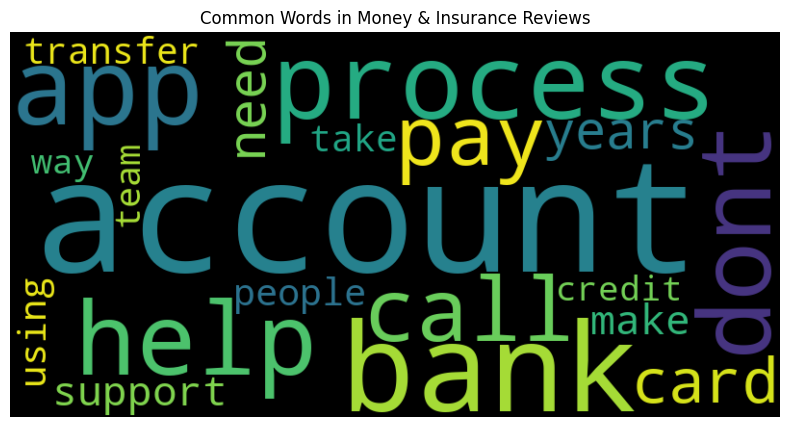

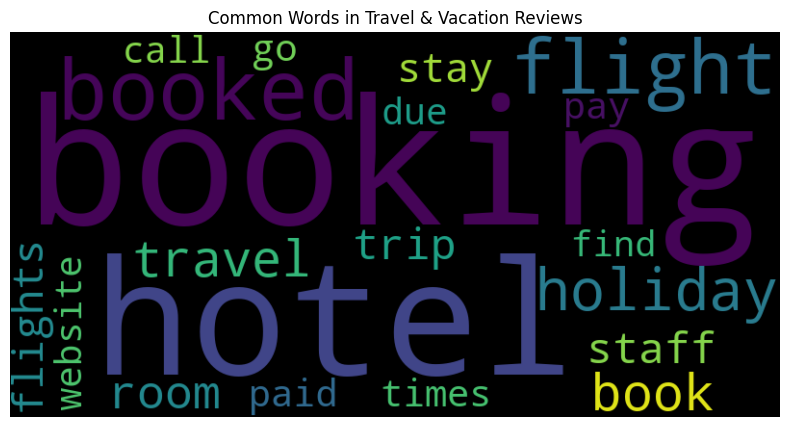

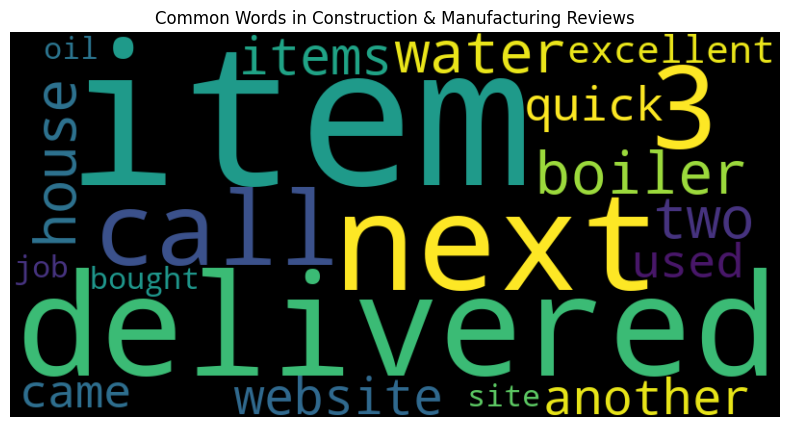

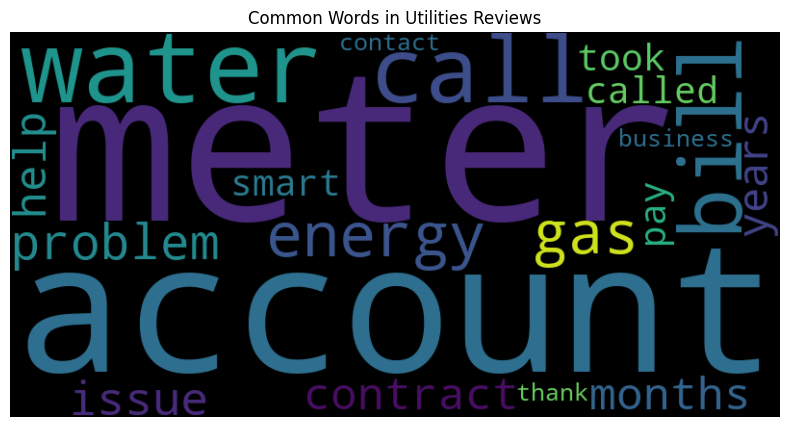

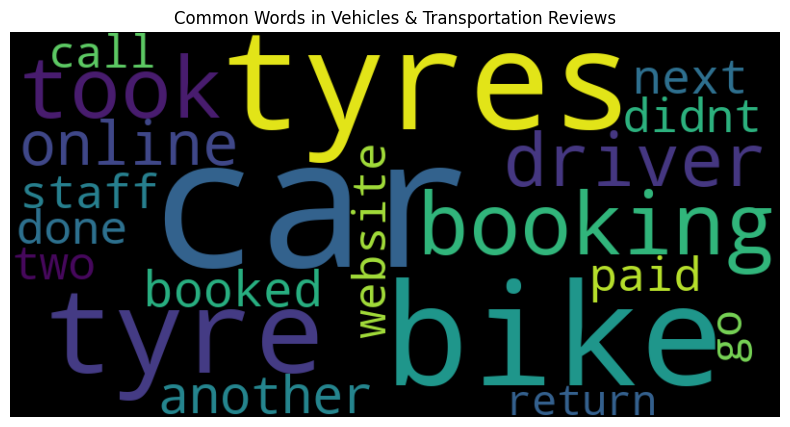

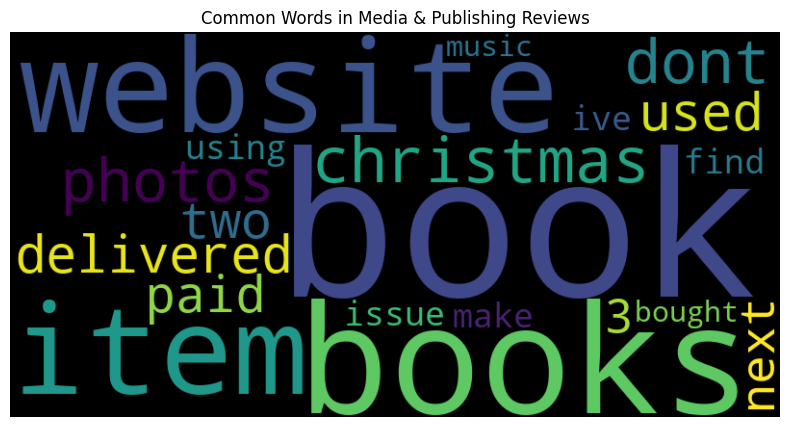

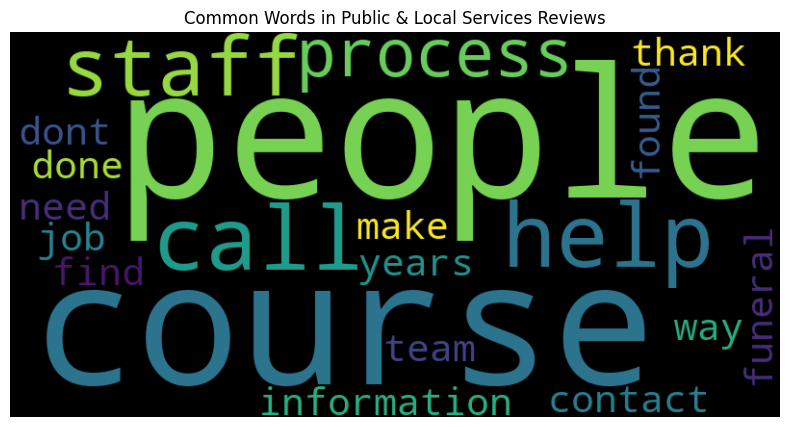

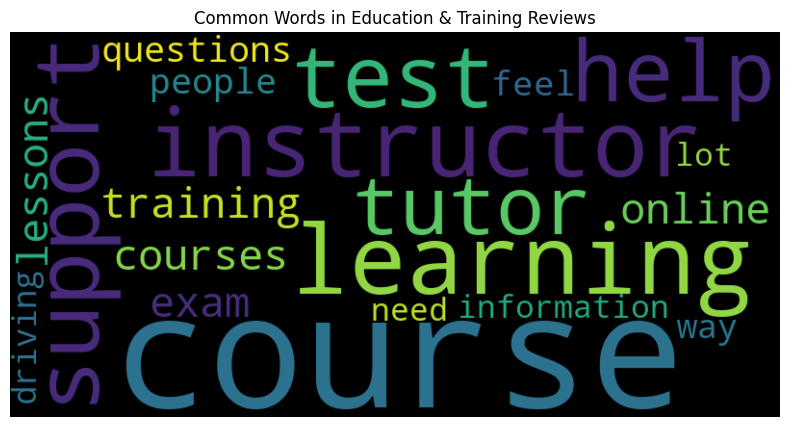

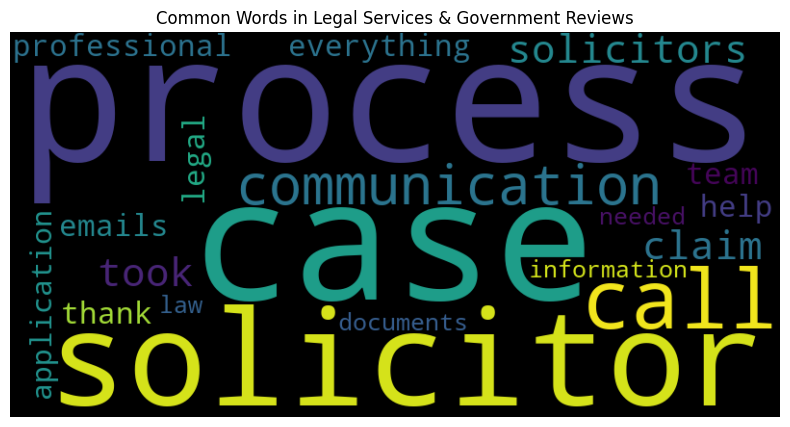

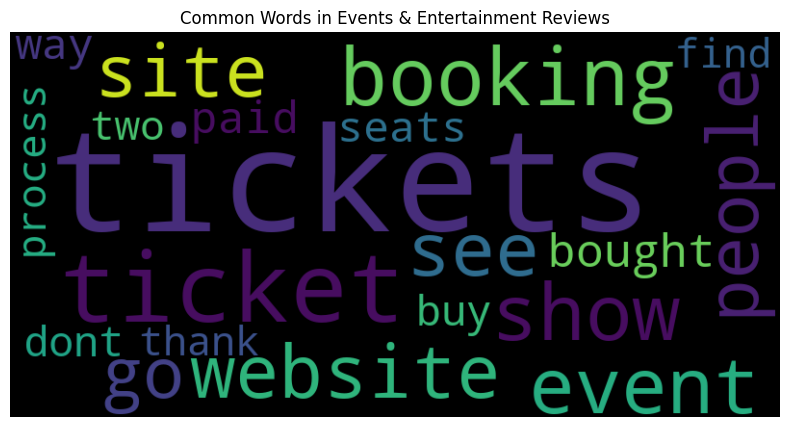

In [43]:
for category, common_words in edited_word_dict.items():
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(dict(common_words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Common Words in {category} Reviews')
    plt.show()

After simple preprocessing the categories seem really clear from the word clouds. Just by looking at these word clouds we can start to make sense of topics. 

We may want to consider looking into what the more interesting problem would be categorizing the product categories or the star ratings. Both are possible with the data given although star ratings may be more challenging especially when distiguishing between the inbetween (ie. 2 and 3 star) ratings. 